In [ ]:
# Cement

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class)

In [ ]:


# cement
cement = ResourceModel(resource_group = 'nmm', resource = 'cement', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)
# cement net trade
# Historical export per region for Cement (Mtonne), 1970-2000 + 2100 (constant from 2000 on) 
# (because export and import did not add up to 0, import has been increased by 25%, see Roorda, page 13)

# production unit: Mt
       
all = all_regions_list_class[:-1]
cement_grouping = {'all' : all}

cement.data_grouped_regions(regions_grouping = cement_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
cement.sum_IMAGE_drivers_regions(regions_dict=None)

cement.match_MAT_data_to_regions_year(match_external_regions=False)
cement.calculate_historic_other_fraction()

In [3]:
# Fit models 
cement.calculate_regressors(cement.historic_consumption_data)
cement.fit_models(best_rmse_models=None)

# Best models
cement.best_rmse_models
cement.merged_rmse_r2

# project based on best model
cement.project_on_total(all_regions_list_class[:-1])

ValueError: cannot convert float NaN to integer

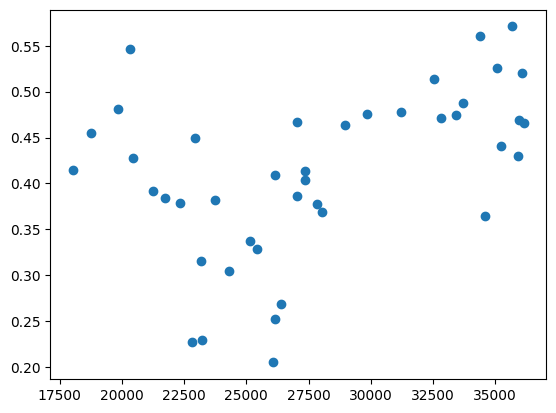

In [4]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in cement.cons_capita.columns:
    ax.scatter(cement.gdp_pc[region], 
               cement.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
    ax.plot(cement.region_model_match.get(region).predict(np.arange(1, 40001).reshape(-1, 1)),
            color = color_dict.get(region))

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

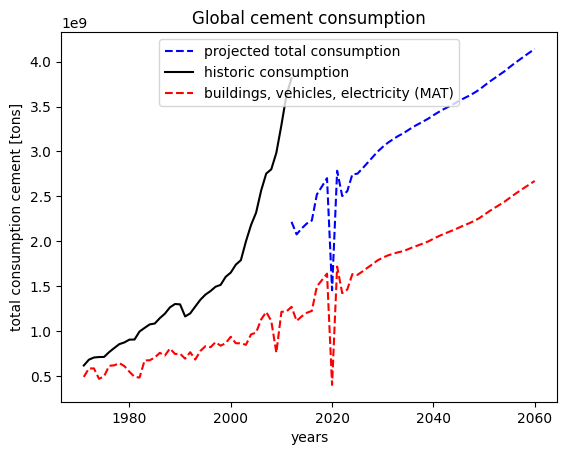

In [ ]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(cement.projection_per_region_total.sum(axis = 1) + cement.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(cement.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(cement.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption cement [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global cement consumption")
ax.legend(loc = 'upper center')